# Deployment 4: radiated self-RFI lines (suspended bowtie, July 19–20, 2025)

Focused follow-up to `explore_24h_july19_20.ipynb`: a set of persistent narrowband lines (none in the FM band, none of them the intentional comb) appears in the antenna data. This notebook collects the evidence that they are **radiated, on-site, instrument-generated RFI**, addresses the external-transmitter alternative, and shows at which processing stage the lines become visible in waterfalls (raw / comb-removed / DPSS-subtracted).

Key tests:
- **Load test**: lines present with the antenna connected, absent on the internal 50 Ω load → they enter over the air (and the conducted/digital alternative is excluded).
- **Geometry test** (gain-free): the line-to-comb power ratio differs strongly between antennas → the source is in the near field (on site), not a far-field transmitter.
- **Coherence test**: lines survive 9 h of coherent cross-correlation averaging → fixed-location, fixed-phase source (note: this separates fixed transmitters from sky/moving sources, but *not* external-fixed from internal).
- **Grid alignment**: statistically, the line population prefers exact FFT-channel centers/boundaries → clock-derived synthesis. (Per line this is weak — channelization only localizes a tone to ±~60 kHz — and an accidental free-running radiator need not be grid-aligned; the argument is statistical and points at clock-derived spurs.)

Data: key '2' = suspended bowtie (verified in the 24-h notebook); times site-local (America/Denver).

In [1]:
import glob
import json
from collections import defaultdict
from datetime import datetime
from zoneinfo import ZoneInfo

import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, get_sun
from astropy.time import Time
import h5py
import hera_filters
import matplotlib.colors as colors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter

MTN = ZoneInfo("America/Denver")
LAT, LON = 39.2477, -113.4033
HHMM = mdates.DateFormatter("%H:%M", tz=MTN)


def dnum(t):
    if np.ndim(t) == 0:
        return mdates.date2num(datetime.fromtimestamp(t, tz=MTN))
    return np.array([mdates.date2num(datetime.fromtimestamp(x, tz=MTN)) for x in np.asarray(t)])

In [2]:
%matplotlib widget

## Load: bowtie autos for the 24 h window + switch states

Same read as the 24-h notebook (key '2' raw, rfswitch stream). The other antennas and the cross-correlations are accumulated as night averages in a second pass below — they are only needed as summary spectra.

In [3]:
KEY = "2"
W0 = datetime(2025, 7, 19, 8, 45, tzinfo=MTN).timestamp()
W1 = datetime(2025, 7, 20, 9, 15, tzinfo=MTN).timestamp()
fnames = sorted(
    glob.glob("../../../data/deployment4/corr_data/corr_20250719_*.h5")
    + glob.glob("../../../data/deployment4/corr_data/corr_20250720_*.h5")
)
T, D, SWT, SWS = [], [], [], []
freq = None
nbad = 0
for fn in fnames:
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[0] > W1 or t[-1] < W0:
                continue
            D.append(f[f"data/{KEY}"][()].astype(np.float32))
            T.append(t)
            if "metadata" in f and "rfswitch_ts" in f["metadata"]:
                SWT.extend(datetime.fromisoformat(s).timestamp() for s in json.loads(f["metadata/rfswitch_ts"][()]))
                SWS.extend(s["sw_state"] for s in json.loads(f["metadata/rfswitch"][()]))
            if freq is None:
                freq = np.array(json.loads(f["header/freqs"][()]))
                dt = float(f["header"].attrs["integration_time"])
    except OSError:
        nbad += 1
times = np.concatenate(T)
data = np.concatenate(D)
sw_t, sw_s = np.array(SWT), np.array(SWS)
order = np.argsort(sw_t)
sw_t, sw_s = sw_t[order], sw_s[order]
ntimes, nchan = data.shape
freq_Hz = freq * 1e6
comb_chans = np.arange(0, nchan, 16)
print(f"{len(T)} files ({nbad} unreadable skipped), {data.shape}")

# switch-state labels with transition and report-age guards
ix = np.clip(np.searchsorted(sw_t, times, side="right") - 1, 0, len(sw_t) - 1)
state = sw_s[ix]
report_age = times - sw_t[ix]
chg_t = sw_t[1:][np.diff(sw_s) != 0]
j = np.searchsorted(chg_t, times)
near_chg = np.zeros(ntimes, bool)
for off in (-1, 0):
    jj = np.clip(j + off, 0, len(chg_t) - 1)
    near_chg |= np.abs(times - chg_t[jj]) < 3.0
corrupt = (data < 0) | (data > 1.5e9)
ant = (state == 0) & ~near_chg & (report_age <= 10.0) & ~corrupt.any(axis=1)

# day/night from sun altitude
loc = EarthLocation(lat=LAT * u.deg, lon=LON * u.deg)
tgrid = np.arange(times[0], times[-1], 300.0)
sun_alt = get_sun(Time(tgrid, format="unix")).transform_to(AltAz(obstime=Time(tgrid, format="unix"), location=loc)).alt.deg
sunset = tgrid[np.nonzero((sun_alt[:-1] > 0) & (sun_alt[1:] <= 0))[0]][0]
sunrise = tgrid[np.nonzero((sun_alt[:-1] <= 0) & (sun_alt[1:] > 0))[0]][0]
night = (times > sunset) & (times < sunrise)
WORK_END = datetime(2025, 7, 19, 13, 0, tzinfo=MTN).timestamp()
day = (times > WORK_END) & ~night & (times < sunset + 86400)
print(f"antenna-state: {ant.sum()} ints; night {(ant & night).sum()}, day (excl. work) {(ant & day).sum()}")

304 files (1 unreadable skipped), (72960, 1024)
antenna-state: 60203 ints; night 29571, day (excl. work) 27352


In [4]:
# pass 2: night antenna-state averages for other autos and the crosses involving the bowtie.
# the cross-correlations are averaged COHERENTLY over the whole night: sky fringes and
# incoherent signals average down, fixed-phase tones survive
S = {k: np.zeros(nchan) for k in ["0", "3", "4"]}
C = {p: np.zeros(nchan, complex) for p in ["02", "24"]}
nacc = 0
for fn in fnames:
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[-1] < sunset or t[0] > sunrise:
                continue
            ixf = np.clip(np.searchsorted(times, t), 0, ntimes - 1)
            ok = (np.abs(times[ixf] - t) < 0.5) & ant[ixf] & night[ixf]
            if ok.sum() < 10:
                continue
            for k in S:
                S[k] += f[f"data/{k}"][()][ok].sum(axis=0)
            for p in C:
                C[p] += f[f"data/{p}"][()][ok].sum(axis=0)
            nacc += ok.sum()
    except OSError:
        continue
for k in S:
    S[k] /= nacc
for p in C:
    C[p] /= nacc
print(f"{nacc} night integrations averaged for ants 0/3/4 and crosses 02/24")

sp_night = np.median(data[ant & night], axis=0)
sp_day = np.median(data[ant & day], axis=0)
sp_load = np.median(data[night & np.isin(state, (128, 160, 224))], axis=0)
coh24 = np.abs(C["24"]) / np.sqrt(sp_night * S["4"])
coh02 = np.abs(C["02"]) / np.sqrt(S["0"] * sp_night)

29571 night integrations averaged for ants 0/3/4 and crosses 02/24


/tmp/ipykernel_436345/2308408240.py:33: RuntimeWarning: invalid value encountered in sqrt
  coh24 = np.abs(C["24"]) / np.sqrt(sp_night * S["4"])


## Line identification and the evidence table

Lines = non-comb channels with > 0.5 dB excess over a running-median baseline in the night antenna spectrum (50–246 MHz; below 50 MHz the short baseline keeps the sky partially coherent between antennas, which would confuse the coherence column). For each line: excess on antenna vs load, in the other antennas, day-vs-night difference, 9-h cross coherence, and the split of power between the peak channel and its strongest neighbour (q ≈ 0: tone at channel centre; q ≈ 0.5: tone at channel boundary).

In [5]:
def line_excess(sp):
    sm = median_filter(sp, 17, mode="nearest")
    with np.errstate(all="ignore"):
        e = 10 * np.log10(np.abs(sp / np.where(sm > 0, sm, 1)))
    e[comb_chans] = np.nan
    e[0] = np.nan
    return e


exc = {
    "ant": line_excess(sp_night),
    "day": line_excess(sp_day),
    "load": line_excess(sp_load),
    "a0": line_excess(S["0"]),
    "a3": line_excess(S["3"]),
    "a4": line_excess(S["4"]),
}

band = (freq >= 50) & (freq <= 246)
fm_band = (freq >= 88) & (freq <= 108)
LINE_DB = 0.5
is_line = band & ~fm_band & (np.nan_to_num(exc["ant"]) > LINE_DB)
# group adjacent flagged channels into single lines, keep the peak channel
lines = []
idx = np.nonzero(is_line)[0]
for ch in idx:
    if lines and ch - lines[-1][-1] <= 1:
        lines[-1].append(ch)
    else:
        lines.append([ch])
lines = [grp[int(np.argmax([exc["ant"][c] for c in grp]))] for grp in lines]

sm_n = median_filter(sp_night, 17, mode="nearest")
print(f"{len(lines)} lines (non-comb, non-FM, > {LINE_DB} dB at night)")
print(f"{'freq':>8} {'chan':>5} {'night':>6} {'day':>6} {'load':>6} {'ant0':>6} {'ant3':>6} {'ant4':>6} {'coh24':>6} {'q':>5}")
for ch in lines:
    p_main = sp_night[ch] - sm_n[ch]
    nb = ch + (1 if (sp_night[ch + 1] - sm_n[ch + 1]) > (sp_night[ch - 1] - sm_n[ch - 1]) else -1)
    p_nb = max(sp_night[nb] - sm_n[nb], 0) if nb not in comb_chans else 0
    q = p_nb / max(p_main + p_nb, 1)
    print(
        f"{freq[ch]:8.2f} {ch:5d} {exc['ant'][ch]:6.2f} {exc['day'][ch]:6.2f} {exc['load'][ch]:6.2f} "
        f"{exc['a0'][ch]:6.2f} {exc['a3'][ch]:6.2f} {exc['a4'][ch]:6.2f} {coh24[ch]:6.3f} {q:5.2f}"
    )

49 lines (non-comb, non-FM, > 0.5 dB at night)
    freq  chan  night    day   load   ant0   ant3   ant4  coh24     q
   63.96   262   0.68   0.56   2.79  -0.27  -0.02  -0.07  0.060  0.00
  108.89   446   0.53   0.00   0.00   2.78   0.08   0.06  0.072  0.00
  112.06   459   0.88   0.20   0.00  -0.02   0.68   0.97  0.213  0.43
  113.04   463   0.53   0.06   0.00   0.00   0.61   0.32  0.176  0.00
  113.53   465   1.26   0.47   0.00   0.00   1.04   0.14  0.172  0.00
  114.50   469   1.50   0.52   0.00   0.00   2.22   0.60  0.209  0.35
  115.97   475   1.13   0.69   0.00   0.00   2.76   0.85  0.228  0.43
  117.43   481   1.16   0.81   0.00   0.30   1.96   0.76  0.200  0.00
  118.90   487   1.40   1.13   0.00  -0.02   1.54   1.19  0.253  0.20
  120.36   493   0.85   0.69   0.00   0.00   0.71   0.43  0.175  0.24
  121.83   499   1.88   1.48   0.00   0.00   1.56   1.03  0.246  0.42
  123.05   504   1.21   0.67   0.00   0.00   0.88   1.06  0.235  0.47
  124.51   510   0.80   0.47   0.00   3.02 

## The headline figure: present on antenna, absent on the internal load

Three zooms of the detrended night spectra. The intentional comb (masked here) also vanishes on the load — an internal consistency check that the load state really disconnects the antenna.

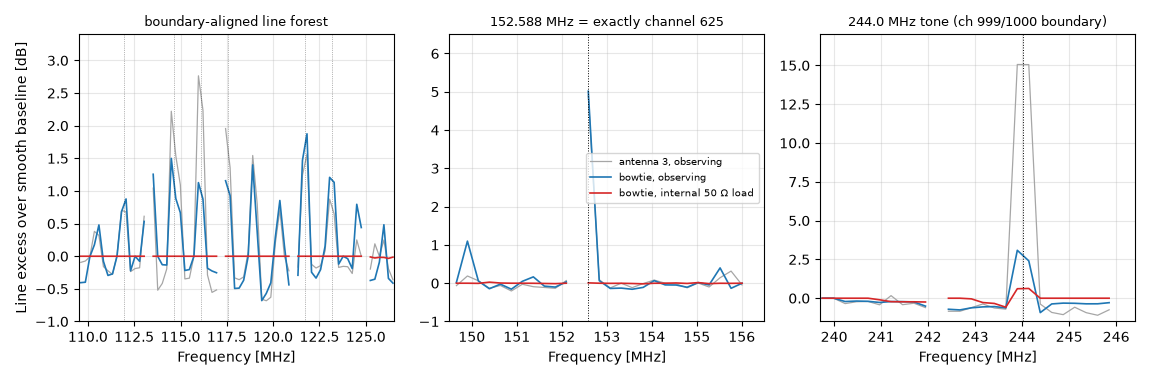

In [6]:
panels = [(109.5, 126.5, -1, 3.4, "boundary-aligned line forest"),
          (149.5, 156.5, -1, 6.5, "152.588 MHz = exactly channel 625"),
          (239.7, 246.4, -1.5, 17, "244.0 MHz tone (ch 999/1000 boundary)")]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
for ax, (f0, f1, y0, y1, ttl) in zip(axes, panels):
    s = (freq >= f0) & (freq <= f1)
    ax.plot(freq[s], exc["a3"][s], lw=0.9, c="0.65", label="antenna 3, observing")
    ax.plot(freq[s], exc["ant"][s], lw=1.2, c="C0", label="bowtie, observing")
    ax.plot(freq[s], exc["load"][s], lw=1.2, c="C3", label="bowtie, internal 50 $\\Omega$ load")
    ax.set_xlim(f0, f1)
    ax.set_ylim(y0, y1)
    ax.set_title(ttl, fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Line excess over smooth baseline [dB]")
axes[1].legend(fontsize=7.5, loc="center right")
for b in (458.5, 469.5, 475.5, 481.5, 498.5, 504.5):
    axes[0].axvline(b * (freq[1] - freq[0]), ls=":", c="k", lw=0.5, alpha=0.55)
axes[1].axvline(freq[625], ls=":", c="k", lw=0.7)
axes[2].axvline(999.5 * (freq[1] - freq[0]), ls=":", c="k", lw=0.7)
plt.tight_layout()
plt.show()
# fig.savefig("/home/christian/Downloads/eigsep_radiated_selfRFI.pdf", dpi=200)

## Is it external? The discriminating arguments

What does **not** discriminate external fixed transmitters from our own accidental radiators:
- *Day/night constancy*: 24/7 services exist (FM, nav beacons).
- *Cross-correlation coherence over hours*: any fixed transmitter is phase-stable on a fixed baseline (the FM stations show coherence 0.08–0.43 too). It only excludes sky/moving sources.
- *Grid alignment of a single line*: channelization localizes a tone to ±~60 kHz, so any one "alignment" has ⅔ chance odds — and an accidental free-running radiator (SMPS, random crystal) need not be grid-aligned at all. Only *clock-derived* spurs must be.

What **does**:
- *The load test*: present on antenna, absent on 50 Ω load → radiated, over the air (excludes conducted/digital injection).
- *Near-field geometry (gain-free)*: for a far-field source, the line-to-comb power ratio would be the same in every antenna (both signals arrive as plane waves; receiver gains cancel in the ratio). Measured below, it varies by an order of magnitude between antennas metres apart → the source is **on site**, and at a different location than the transmit antenna.
- *Population statistics of grid alignment*: individually weak, but the q-distribution of all lines clusters at 0 and 0.5 (centres and boundaries) rather than uniform → clock-derived synthesis.

Remaining caveat: the 111–137 MHz forest overlaps the aeronautical band, where VOR/ILS beacons are fixed, continuous, and coherent — external look-alikes. The line table above gives frequencies to ±0.1 MHz for a cross-check against FAA allocations around the site; the near-field test below is the in-data argument.

line(244) / comb(neighbouring lines) power ratio per antenna:
   bowtie: 0.0017
    ant 3: 1.1361
    ant 4: 0.2594


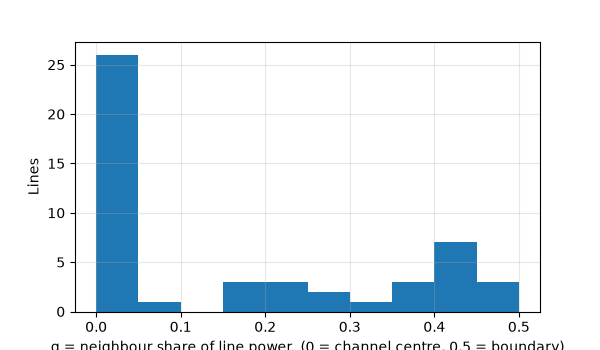

27 centre-aligned, 10 boundary-aligned, of 49 lines
(a uniformly distributed tone offset would put ~20% in each of those bins)


In [7]:
# near-field test at the 244 MHz tone: line power relative to the received comb, per antenna.
# both are radiated on-site signals; if the line came from the same place as the comb
# transmitter (or from far field), this ratio would be antenna-independent
line_chs = (999, 1000)
comb_ref = (992, 1008)
specs = {"bowtie": sp_night, "ant 3": S["3"], "ant 4": S["4"]}
print("line(244) / comb(neighbouring lines) power ratio per antenna:")
for name, sp in specs.items():
    sm = median_filter(sp, 17, mode="nearest")
    pl = sum(max(sp[c] - sm[c], 0) for c in line_chs)
    pc = sum(max(sp[c] - sm[c], 0) for c in comb_ref)
    print(f"  {name:>7}: {pl / pc:.4f}")

# alignment statistics over the line population
qs = []
for ch in lines:
    p_main = sp_night[ch] - sm_n[ch]
    nb = ch + (1 if (sp_night[ch + 1] - sm_n[ch + 1]) > (sp_night[ch - 1] - sm_n[ch - 1]) else -1)
    p_nb = max(sp_night[nb] - sm_n[nb], 0) if nb not in comb_chans else 0
    qs.append(p_nb / max(p_main + p_nb, 1))
qs = np.array(qs)
plt.figure(figsize=(6, 3.5))
plt.hist(qs, bins=np.linspace(0, 0.5, 11))
plt.xlabel("q = neighbour share of line power  (0 = channel centre, 0.5 = boundary)")
plt.ylabel("Lines")
plt.grid(alpha=0.3)
plt.show()
print(f"{(qs < 0.1).sum()} centre-aligned, {(qs > 0.4).sum()} boundary-aligned, of {len(qs)} lines")
print("(a uniformly distributed tone offset would put ~20% in each of those bins)")

## Visibility: raw vs comb-removed vs DPSS-subtracted waterfalls

The practical question for the paper: at which processing stage do these lines show up in a waterfall? Night-time antenna-state data on a 32-s grid, full band, three processings:
1. **raw**: log power — the bandpass spans ~40 dB, so a 0.5–5 dB line is invisible;
2. **comb removed**: the transmitted comb channels excised (it is confined to single channels, so excision = removal) — the display de-clutters but the bandpass still hides the lines;
3. **DPSS-subtracted**: residual relative to the smooth (300 ns) bandpass model in dB — the lines stand out as unbroken vertical stripes.
A zoomed second row shows the 108–160 MHz region containing the line forest and the 152.588 MHz line.

In [8]:
# 32-s binned night waterfall (antenna state only)
TBIN = 30 * dt
edges = np.arange(sunset, sunrise + TBIN, TBIN)
ibin = np.digitize(times, edges) - 1
inw = (ibin >= 0) & (ibin < len(edges) - 1)
w = (ant & night & inw).astype(np.float32)
davg = np.zeros((len(edges) - 1, nchan))
wsum = np.zeros(len(edges) - 1)
np.add.at(davg, ibin[inw], (data[inw].astype(np.float64)) * w[inw, None])
np.add.at(wsum, ibin[inw], w[inw])
davg = np.where(wsum[:, None] > 9, davg / np.maximum(wsum[:, None], 1), np.nan)
tb = 0.5 * (edges[:-1] + edges[1:])
valid = wsum > 9
print(f"{valid.sum()} valid night bins")

# DPSS model per row (fit weights: comb + DC + seeded strong channels)
med_spec = np.nanmedian(davg[valid], axis=0)
smooth = median_filter(med_spec, size=17, mode="nearest")
fr = (med_spec - smooth) / smooth
apriori = np.zeros(nchan, bool)
apriori[comb_chans] = True
apriori[0] = True
sg = 1.4826 * np.median(np.abs(fr[~apriori] - np.median(fr[~apriori])))
flags_fit = apriori | (~apriori & (np.abs(fr) > 6 * sg))
Af = hera_filters.dspec.dpss_operator(freq_Hz, filter_centers=[0], filter_half_widths=[300e-9], eigenval_cutoff=[1e-9])[0].real
Ff = hera_filters.dspec.fit_solution_matrix((~flags_fit).astype(float), Af)
dv = np.where(np.isnan(davg), 0.0, davg)
mdl = (Af @ (Ff @ dv.T)).T
with np.errstate(all="ignore"):
    resid_db = 10 * np.log10(davg / mdl)

comb_mask = np.zeros(nchan, bool)
comb_mask[comb_chans] = True

1000 valid night bins


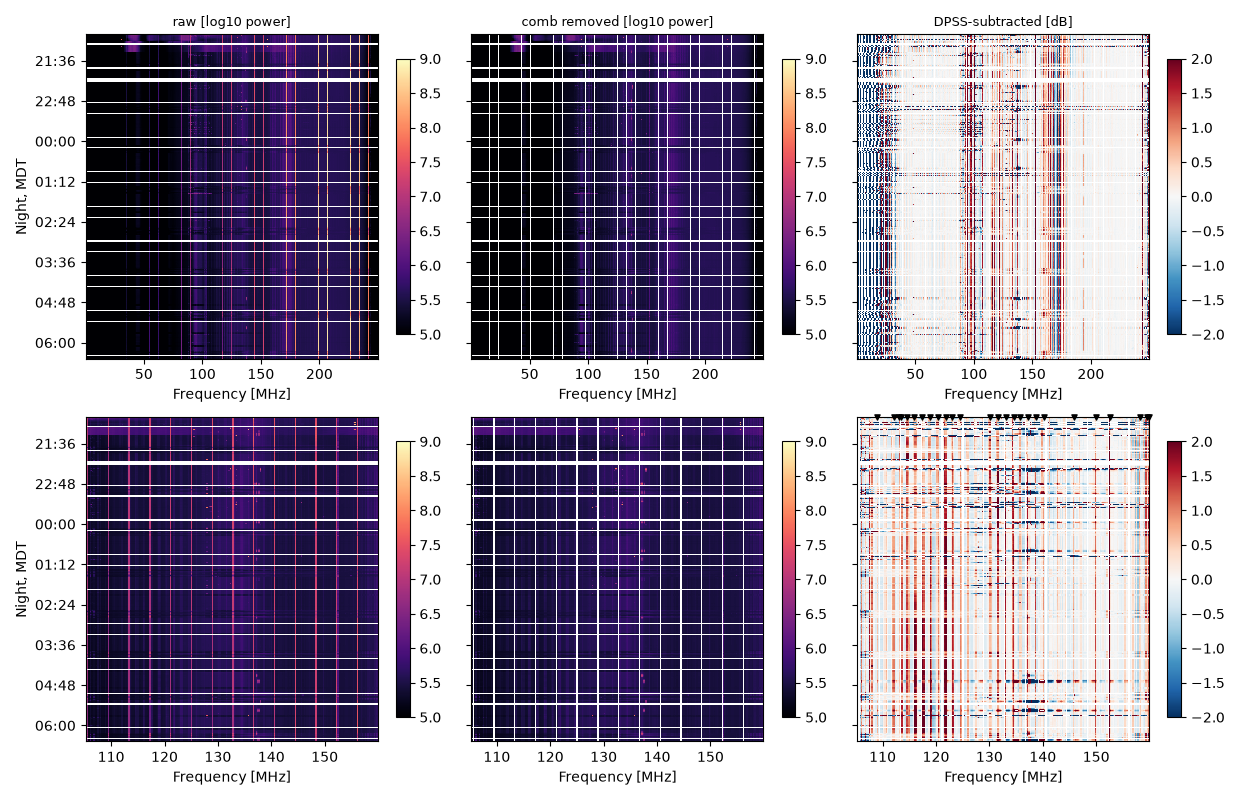

In [9]:
views = [
    ("raw [log10 power]", np.log10(np.abs(davg) + 1), dict(cmap="magma", vmin=5, vmax=9)),
    ("comb removed [log10 power]", np.log10(np.abs(np.where(comb_mask, np.nan, davg)) + 1), dict(cmap="magma", vmin=5, vmax=9)),
    ("DPSS-subtracted [dB]", np.where(comb_mask, np.nan, resid_db), dict(cmap="RdBu_r", vmin=-2, vmax=2)),
]
zoom = (105, 160)
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8), sharey=True)
for col, (ttl, img, kw) in enumerate(views):
    for rowi, (f0, f1) in enumerate([(freq[1], freq[-1]), zoom]):
        ax = axes[rowi, col]
        s = (freq >= f0) & (freq <= f1)
        im = ax.imshow(
            img[:, s],
            aspect="auto",
            interpolation="none",
            extent=[freq[s][0], freq[s][-1], dnum(tb[-1]), dnum(tb[0])],
            **kw,
        )
        if rowi == 0:
            ax.set_title(ttl, fontsize=9)
        ax.yaxis.set_major_formatter(HHMM)
        ax.set_xlabel("Frequency [MHz]")
        plt.colorbar(im, ax=ax, shrink=0.85)
for rowi in range(2):
    axes[rowi, 0].set_ylabel("Night, MDT")
# tick markers for the line channels above the zoomed residual view
zlines = [freq[ch] for ch in lines if zoom[0] < freq[ch] < zoom[1]]
axes[1, 2].scatter(zlines, [dnum(tb[0])] * len(zlines), marker="v", s=14, c="k", clip_on=False, zorder=5)
plt.tight_layout()
plt.show()

In [10]:
# quantitative visibility: line contrast vs the display dynamic range of each view
contrast = np.nanmedian([exc["ant"][ch] for ch in lines])
print(f"median line excess: {contrast:.1f} dB")
print(f"raw / comb-removed views: color range spans {10 * (9 - 5):.0f} dB of bandpass -> lines are < {100 * contrast / 40:.0f}% of the colormap, invisible")
print(f"DPSS-subtracted view: color range 4 dB -> lines are {min(100 * contrast / 4, 100):.0f}% of the colormap, clearly visible as unbroken vertical stripes")

median line excess: 1.1 dB
raw / comb-removed views: color range spans 40 dB of bandpass -> lines are < 3% of the colormap, invisible
DPSS-subtracted view: color range 4 dB -> lines are 27% of the colormap, clearly visible as unbroken vertical stripes


## Summary

**49 persistent narrowband lines** (non-comb, non-FM, > 0.5 dB, 50–246 MHz) populate the night spectrum of the suspended bowtie: a forest through 109–141 MHz, the strong 152.588 MHz line (exactly channel 625, +5 dB), a cluster at 158–181 MHz, and the 244.0 MHz tone (channel 999/1000 boundary).

Evidence they are radiated, on-site, instrument-generated:
- **Load test**: every line drops to 0.00 dB on the internal 50 Ω load (the comb does too — confirming the load really disconnects the antenna). Sole exception: the 64.0 MHz spur *survives* on load at +2.8 dB → that one is conducted/internal, not radiated.
- **Near-field geometry** (gain-free): the 244 MHz line-to-comb power ratio is 0.002 (bowtie), 1.14 (ant 3), 0.26 (ant 4) — a spread of ~3 orders of magnitude between antennas metres apart. A far-field transmitter gives the same ratio everywhere; this source is on site, nearest antenna 3.
- **Coherence**: the lines survive 9 h of coherent cross-correlation averaging (coh ≈ 0.1–0.43 vs 0.001 for clean channels) → fixed-location, continuous source. (Not by itself proof of internal origin — fixed external beacons are also coherent.)
- **Grid alignment, statistically**: 27 of 49 lines sit at exact channel centres and 10 at exact boundaries (~75% aligned where a uniform tone distribution gives ~40%) → frequencies derived from the instrument's own 500 MHz clock family.
- **Day/night**: the lines are present in both epochs; the strong ones (152.6, 244.0 MHz) hold their absolute power, while the weak-line estimates scatter by ~3 dB (median day$-$night $-1.9$ dB) — limited by the brighter, busier daytime floor, not by on/off behaviour. None shows the switching pattern of human-activity RFI. (The *excess* metric drops by day simply because the floor is higher.)

**Caveat kept honest**: the 109–137 MHz forest lies in the aeronautical band where VOR/ILS beacons are fixed, continuous and coherent; the line table provides frequencies for an FAA allocation cross-check. The near-field and load arguments are the in-data discriminators.

**Visibility** (the practical question): the lines are invisible in raw and comb-removed waterfalls — at 0.5–5 dB they are < 3% of the ~40 dB bandpass color range. They become unmistakable, unbroken vertical stripes in the DPSS-subtracted waterfall on a ±2 dB scale. Comb removal alone does not reveal them; bandpass flattening does.

In [11]:
print("=== Radiated self-RFI lines, deployment 4, suspended bowtie ===")
print(f"{len(lines)} persistent non-comb, non-FM lines > {LINE_DB} dB (night, 50-246 MHz)")
print("all vanish on the internal 50-ohm load except the conducted 64.0 MHz spur")
print(f"244 MHz tone: bowtie {exc['ant'][999]:+.1f} dB, ant3 {exc['a3'][999]:+.1f} dB, ant4 {exc['a4'][999]:+.1f} dB")
print("  line/comb power ratio spans ~3 orders of magnitude between antennas -> near-field, on-site source")
print(f"alignment: {(qs < 0.1).sum()} centre + {(qs > 0.4).sum()} boundary aligned of {len(qs)} lines (uniform would give ~20% each)")

# day/night stability in ABSOLUTE line power (the excess metric is biased: the daytime
# floor is higher, so a constant line shows lower *excess* by day)
sm_d = median_filter(sp_day, 17, mode="nearest")
ratios = []
for ch in lines:
    pn = sp_night[ch] - sm_n[ch]
    pd = sp_day[ch] - sm_d[ch]
    if pn > 0 and pd > 0:
        ratios.append(10 * np.log10(pd / pn))
print(f"absolute line power, day vs night: median {np.median(ratios):+.2f} dB, "
      f"median |diff| {np.median(np.abs(ratios)):.2f} dB ({len(ratios)}/{len(lines)} lines measurable both epochs)")
print()
print("visibility: invisible in raw and comb-removed waterfalls (bandpass spans ~40 dB);")
print("clearly visible as unbroken vertical stripes in the DPSS-subtracted waterfall (+-2 dB scale)")

=== Radiated self-RFI lines, deployment 4, suspended bowtie ===
49 persistent non-comb, non-FM lines > 0.5 dB (night, 50-246 MHz)
all vanish on the internal 50-ohm load except the conducted 64.0 MHz spur
244 MHz tone: bowtie +3.1 dB, ant3 +15.1 dB, ant4 +8.1 dB
  line/comb power ratio spans ~3 orders of magnitude between antennas -> near-field, on-site source
alignment: 27 centre + 10 boundary aligned of 49 lines (uniform would give ~20% each)
absolute line power, day vs night: median -1.87 dB, median |diff| 3.02 dB (40/49 lines measurable both epochs)

visibility: invisible in raw and comb-removed waterfalls (bandpass spans ~40 dB);
clearly visible as unbroken vertical stripes in the DPSS-subtracted waterfall (+-2 dB scale)


## Appendix (for the record): calibration noise-injection misfires

A different class of systematic — instrument glitches rather than radiated RFI — kept here for the record. Each row is one ten-state calibration cycle aligned to its start; the bright block is the ×100 noise injection. It shifts switch slot between day and night, fires short, or skips entirely — day and night, instrument-paced.

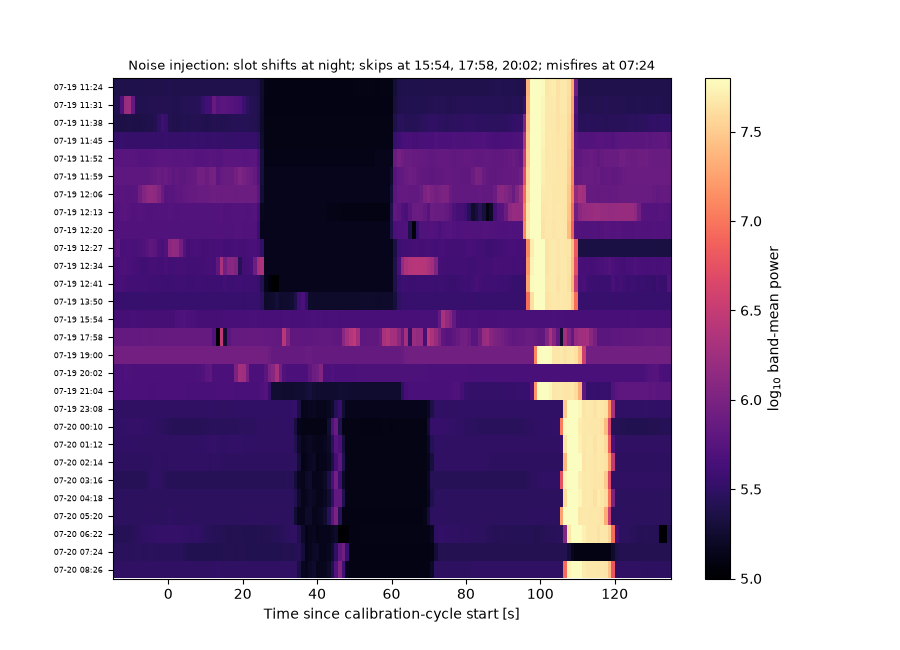

In [12]:
ncm = (freq >= 30) & (freq <= 245)
ncm[comb_chans] = False
bp = data[:, ncm].mean(axis=1)
nz = (state != 0).astype(int)
st_ = np.nonzero(np.diff(nz) == 1)[0] + 1
en_ = np.nonzero(np.diff(nz) == -1)[0] + 1
if nz[0]:
    st_ = np.r_[0, st_]
if nz[-1]:
    en_ = np.r_[en_, ntimes]
events = [(s, e) for s, e in zip(st_, en_) if times[e - 1] - times[s] >= 60 and 128 in state[s:e]]
xgrid = np.arange(-15, 136, 1.0)
img = np.full((len(events), len(xgrid)), np.nan)
labels = []
for k, (s, e) in enumerate(events):
    t0 = times[s]
    m = (times >= t0 - 18) & (times <= t0 + 138)
    img[k] = np.interp(xgrid, times[m] - t0, bp[m])
    labels.append(datetime.fromtimestamp(t0, tz=MTN))
plt.figure(figsize=(9, 6.5))
plt.imshow(np.log10(np.abs(img) + 1), aspect="auto", interpolation="none", cmap="magma",
           extent=[xgrid[0], xgrid[-1], len(events) - 0.5, -0.5], vmin=5, vmax=7.8)
plt.yticks(range(len(events)), [f"{d:%m-%d %H:%M}" for d in labels], fontsize=6)
plt.xlabel("Time since calibration-cycle start [s]")
plt.colorbar(label="log$_{10}$ band-mean power")
plt.title("Noise injection: slot shifts at night; skips at 15:54, 17:58, 20:02; misfires at 07:24", fontsize=9)
plt.show()

## Knobs

- `LINE_DB = 0.5` — line detection threshold; band restricted to 50–246 MHz (below 50 MHz the metres-scale baseline keeps the sky coherent, contaminating the coherence column).
- Load states = {128, 160, 224} (night); antenna state = 0 with ±3 s transition guard and 10 s report-age guard.
- `q` alignment metric uses the strongest neighbour's share of line power; it is PFB-response dependent at the ~10% level.
- The near-field test references comb lines 992/1008 around the 244 MHz tone; any nearby comb pair works.
- DPSS model: 300 ns half-width, fit weights exclude comb + DC + 6σ-seeded channels (the candidate lines are *kept* in the data so they appear in residuals).
- Visibility waterfalls: 32-s bins, night only; color ranges 5–9 (log power) and ±2 dB (residual).
- Follow-ups: FAA VOR/ILS allocation cross-check for the 111–137 MHz forest; cross-phase triangulation of the 244 MHz tone; power-cycle tests on site.